In [1]:
# ================================================================
# IMPORTS
# ================================================================
import glob
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.signal as sig
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold, train_test_split as tts
from sklearn.metrics import roc_auc_score, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device : {device}")
print(f"GPU name     : {torch.cuda.get_device_name(0)}")


Using device : cuda
GPU name     : NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ================================================================
# PARAMETERS
# ================================================================
num_samples = 12800
fs          = 64000
num_classes = 4

data_path = r"C:\dataset"
cls_1 = 'Healthy/*/*.mat'
cls_2 = 'IR&OR/*/*.mat'
cls_3 = 'IR/*/*.mat'
cls_4 = 'OR/*/*.mat'

In [6]:
# ================================================================
# DATA LOADING — raw highpass filtered signal
# ================================================================
def load_files_raw(data_src, num_samples, class_label, fs=64000):
    files     = glob.glob(data_src)
    files     = np.sort(files)
    file_data = []
    sos       = sig.butter(4, 1000, btype='highpass', fs=fs, output='sos')

    for file in files:
        data    = loadmat(file)
        key     = sorted(data.keys())[0]
        signal  = data[key]['Y'][0][0][0][1][2].reshape(-1).astype(np.float64)
        signal  = sig.sosfilt(sos, signal).astype(np.float32)
        n_segs  = int(np.floor(len(signal) / num_samples))
        if n_segs == 0:
            continue
        segments = signal[:n_segs * num_samples].reshape(n_segs, num_samples)
        file_data.append((segments, class_label))

    return file_data

print("Loading raw signals...")
all_file_data  = load_files_raw(os.path.join(data_path, cls_1), num_samples, 0)
all_file_data += load_files_raw(os.path.join(data_path, cls_2), num_samples, 1)
all_file_data += load_files_raw(os.path.join(data_path, cls_3), num_samples, 2)
all_file_data += load_files_raw(os.path.join(data_path, cls_4), num_samples, 3)

for cls, name in enumerate(['Healthy', 'IR&OR', 'IR', 'OR']):
    cls_files = [f for f in all_file_data if f[1] == cls]
    print(f"  {name}: {len(cls_files)} files, "
          f"{sum(len(f[0]) for f in cls_files)} segments")

Loading raw signals...
  Healthy: 400 files, 8001 segments
  IR&OR: 240 files, 4799 segments
  IR: 480 files, 9612 segments
  OR: 400 files, 7994 segments


In [7]:
# ================================================================
# DATALOADER — shape (N, 1, 12800) for Conv+LSTM
# ================================================================
def make_loader_raw(X, y, batch_size=128, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, 12800)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size,
                      shuffle=shuffle, pin_memory=True, num_workers=0)

In [4]:
# ================================================================
# ALL FUNCTION DEFINITIONS
# ================================================================

def files_to_XY(file_list):
    X_list, Y_list = [], []
    for segments, label in file_list:
        X_list.append(segments)
        Y_list.append(np.ones(len(segments)) * label)
    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)
    X = np.unique(X, axis=0)
    idx = np.random.permutation(len(X))
    return X[idx].astype(np.float32), Y[idx].astype(np.int64)


def make_loader_raw(X, y, batch_size=128, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, 12800)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size,
                      shuffle=shuffle, pin_memory=True, num_workers=0)


def train_model(model, train_loader, val_loader, epochs, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5,
                                                      factor=0.5, verbose=True)
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss   = criterion(output, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        correct  = 0
        total    = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output   = model(X_batch)
                val_loss += criterion(output, y_batch).item()
                preds    = output.argmax(dim=1)
                correct  += (preds == y_batch).sum().item()
                total    += y_batch.size(0)

        val_acc = correct / total
        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss/len(train_loader):.4f} | "
                  f"Val Loss: {val_loss/len(val_loader):.4f} | "
                  f"Val Acc: {val_acc*100:.2f}%")
    return model


def evaluate_model(model, test_loader, device, num_classes):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch  = X_batch.to(device)
            output   = model(X_batch)
            probs    = torch.softmax(output, dim=1)
            preds    = probs.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y_batch.numpy())
    return (np.concatenate(all_preds),
            np.concatenate(all_probs),
            np.concatenate(all_labels))


class BearingLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super(BearingLSTM, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=64, stride=8, padding=32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=16, stride=4, padding=8),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.lstm1 = nn.LSTM(input_size=64, hidden_size=128,
                             batch_first=True, bidirectional=True)
        self.drop1 = nn.Dropout(0.3)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=64,
                             batch_first=True, bidirectional=True)
        self.drop2 = nn.Dropout(0.3)

        self.attention = nn.Linear(128, 1)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)              # (batch, 64, 400)
        x = x.permute(0, 2, 1)        # (batch, 400, 64)
        x, _ = self.lstm1(x)          # (batch, 400, 256)
        x     = self.drop1(x)
        x, _ = self.lstm2(x)          # (batch, 400, 128)
        x     = self.drop2(x)
        attn_weights = torch.softmax(self.attention(x), dim=1)
        x            = (x * attn_weights).sum(dim=1)
        x = self.classifier(x)
        return x


print("All functions and model defined successfully!")

All functions and model defined successfully!



FOLD 1/5
Train: 24285 | Test: 6081
Model parameters: 407,269
  Epoch  10/50 | Train Loss: 0.1369 | Val Loss: 0.1842 | Val Acc: 93.54%
  Epoch  20/50 | Train Loss: 0.0755 | Val Loss: 0.1496 | Val Acc: 95.59%
  Epoch  30/50 | Train Loss: 0.0221 | Val Loss: 0.1227 | Val Acc: 97.16%
  Epoch  40/50 | Train Loss: 0.0071 | Val Loss: 0.1752 | Val Acc: 97.24%
  Epoch  50/50 | Train Loss: 0.0047 | Val Loss: 0.2202 | Val Acc: 97.08%

Fold 1: Acc=97.22% | F1=0.9722 | AUC=0.9982


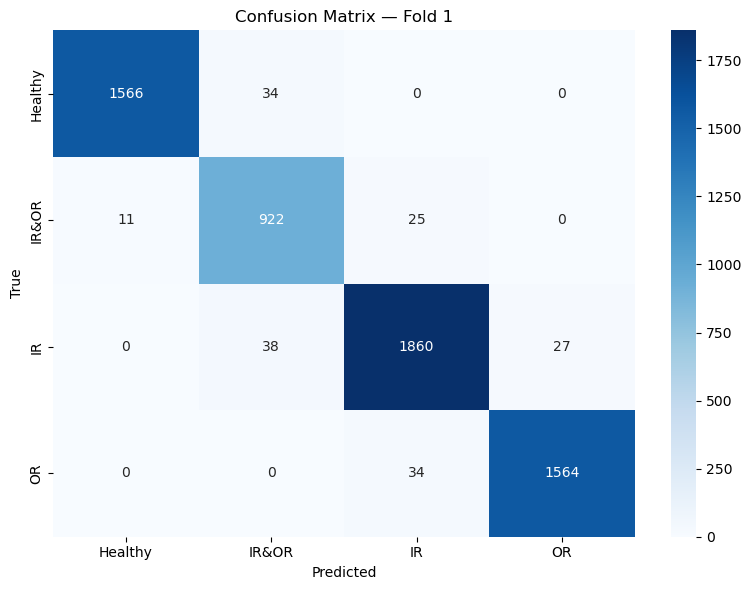


FOLD 2/5
Train: 24265 | Test: 6081
Model parameters: 407,269
  Epoch  10/50 | Train Loss: 0.1174 | Val Loss: 0.1371 | Val Acc: 94.44%
  Epoch  20/50 | Train Loss: 0.0756 | Val Loss: 0.1404 | Val Acc: 95.51%
  Epoch  30/50 | Train Loss: 0.0566 | Val Loss: 0.1126 | Val Acc: 96.33%
  Epoch  40/50 | Train Loss: 0.0155 | Val Loss: 0.1679 | Val Acc: 97.07%
  Epoch  50/50 | Train Loss: 0.0037 | Val Loss: 0.2196 | Val Acc: 96.87%

Fold 2: Acc=97.06% | F1=0.9706 | AUC=0.9980


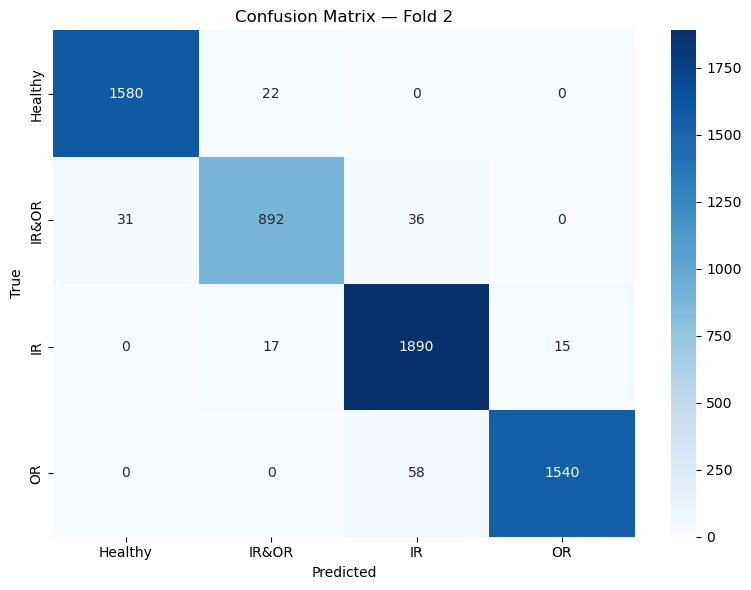


FOLD 3/5
Train: 24303 | Test: 6083
Model parameters: 407,269
  Epoch  10/50 | Train Loss: 0.1170 | Val Loss: 0.1263 | Val Acc: 95.48%
  Epoch  20/50 | Train Loss: 0.0463 | Val Loss: 0.1056 | Val Acc: 96.96%
  Epoch  30/50 | Train Loss: 0.0225 | Val Loss: 0.1172 | Val Acc: 97.12%
  Epoch  40/50 | Train Loss: 0.0133 | Val Loss: 0.1582 | Val Acc: 97.24%
  Epoch  50/50 | Train Loss: 0.0041 | Val Loss: 0.1897 | Val Acc: 97.49%

Fold 3: Acc=96.70% | F1=0.9670 | AUC=0.9981


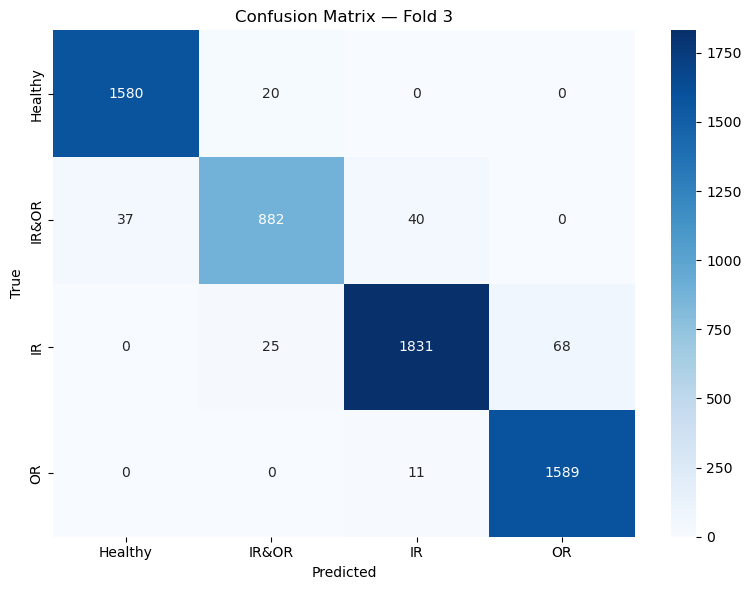


FOLD 4/5
Train: 24244 | Test: 6082
Model parameters: 407,269
  Epoch  10/50 | Train Loss: 0.1058 | Val Loss: 0.1058 | Val Acc: 95.84%
  Epoch  20/50 | Train Loss: 0.0474 | Val Loss: 0.1109 | Val Acc: 96.37%
  Epoch  30/50 | Train Loss: 0.0232 | Val Loss: 0.1234 | Val Acc: 96.70%
  Epoch  40/50 | Train Loss: 0.0088 | Val Loss: 0.1688 | Val Acc: 97.03%
  Epoch  50/50 | Train Loss: 0.0027 | Val Loss: 0.1855 | Val Acc: 97.15%

Fold 4: Acc=96.81% | F1=0.9681 | AUC=0.9975


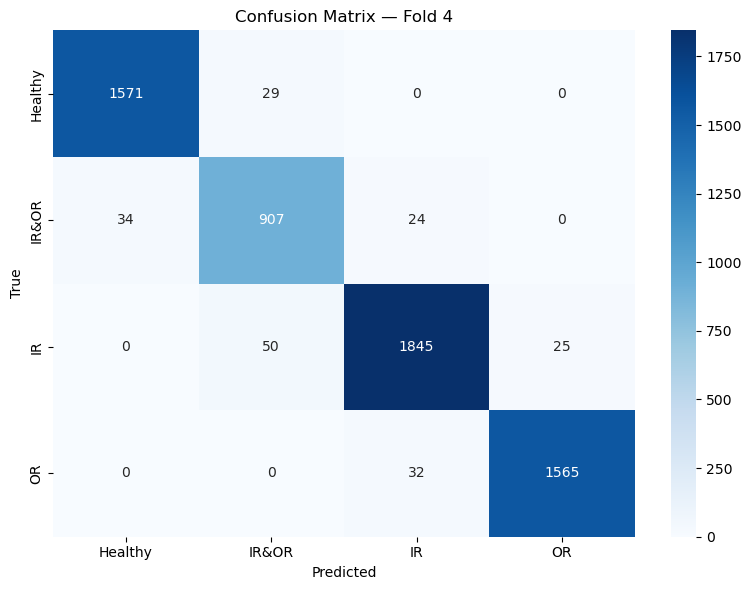


FOLD 5/5
Train: 24267 | Test: 6079
Model parameters: 407,269
  Epoch  10/50 | Train Loss: 0.1932 | Val Loss: 0.2402 | Val Acc: 87.60%
  Epoch  20/50 | Train Loss: 0.1485 | Val Loss: 0.1500 | Val Acc: 93.41%
  Epoch  30/50 | Train Loss: 0.0548 | Val Loss: 0.1322 | Val Acc: 96.50%
  Epoch  40/50 | Train Loss: 0.0229 | Val Loss: 0.1245 | Val Acc: 97.07%
  Epoch  50/50 | Train Loss: 0.0164 | Val Loss: 0.1525 | Val Acc: 97.07%

Fold 5: Acc=96.99% | F1=0.9699 | AUC=0.9977


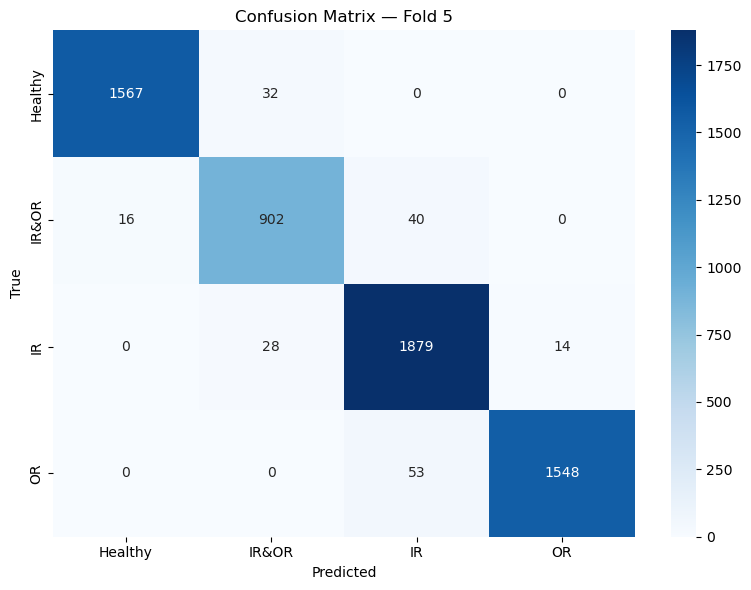


CONV-LSTM CROSS VALIDATION SUMMARY
Accuracy : 96.95% ± 0.18%
F1 Score : 0.9695 ± 0.0018
ROC AUC  : 0.9979 ± 0.0003


In [8]:
# ================================================================
# CROSS VALIDATION
# ================================================================
file_indices = list(range(len(all_file_data)))
file_labels  = [d[1] for d in all_file_data]
skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies, fold_f1s, fold_aucs = [], [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(file_indices, file_labels)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold+1}/5")
    print(f"{'='*50}")

    train_files = [all_file_data[i] for i in train_idx]
    test_files  = [all_file_data[i] for i in test_idx]

    X_train_raw, y_train = files_to_XY(train_files)
    X_test_raw,  y_test  = files_to_XY(test_files)

    # ---- Normalize per sample ----
    X_train_norm = (X_train_raw - X_train_raw.mean(axis=1, keepdims=True)) / \
                   (X_train_raw.std(axis=1,  keepdims=True) + 1e-8)
    X_test_norm  = (X_test_raw  - X_test_raw.mean(axis=1,  keepdims=True)) / \
                   (X_test_raw.std(axis=1,   keepdims=True) + 1e-8)

    print(f"Train: {len(X_train_norm)} | Test: {len(X_test_norm)}")

    from sklearn.model_selection import train_test_split as tts
    X_tr, X_val, y_tr, y_val = tts(X_train_norm, y_train,
                                    test_size=0.1, stratify=y_train,
                                    random_state=42)

    train_loader = make_loader_raw(X_tr,         y_tr,   shuffle=True)
    val_loader   = make_loader_raw(X_val,         y_val)
    test_loader  = make_loader_raw(X_test_norm,   y_test)

    # ---- Build model ----
    model = BearingLSTM(num_classes=4).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {total_params:,}")

    model = train_model(model, train_loader, val_loader, epochs=50, device=device)

    preds, probs, labels = evaluate_model(model, test_loader, device, num_classes=4)
    labels_onehot        = np.eye(4)[labels.astype(int)]

    acc = metrics.accuracy_score(labels, preds)
    f1  = metrics.f1_score(labels, preds, average='micro')
    auc = roc_auc_score(labels_onehot, probs, multi_class='ovr')

    fold_accuracies.append(acc)
    fold_f1s.append(f1)
    fold_aucs.append(auc)

    print(f"\nFold {fold+1}: Acc={acc*100:.2f}% | F1={f1:.4f} | AUC={auc:.4f}")

    fault_type = ['Healthy', 'IR&OR', 'IR', 'OR']
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=fault_type, yticklabels=fault_type, cmap="Blues")
    plt.title(f'Confusion Matrix — Fold {fold+1}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    del model, train_loader, val_loader, test_loader
    gc.collect()
    torch.cuda.empty_cache()

print(f"\n{'='*50}")
print(f"CONV-LSTM CROSS VALIDATION SUMMARY")
print(f"{'='*50}")
print(f"Accuracy : {np.mean(fold_accuracies)*100:.2f}% ± {np.std(fold_accuracies)*100:.2f}%")
print(f"F1 Score : {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"ROC AUC  : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")

In [9]:
# Sanity check — train on random labels, expect ~25% accuracy
# If accuracy is still high with random labels → definite leakage
print("\nSanity check — training with RANDOM labels...")
print("Expected accuracy: ~25% (random chance)")
print("If accuracy is high with random labels → leakage confirmed\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(file_indices, file_labels)):
    if fold > 0:
        break

    train_files = [all_file_data[i] for i in train_idx]
    test_files  = [all_file_data[i] for i in test_idx]

    X_train_raw, y_train = files_to_XY(train_files)
    X_test_raw,  y_test  = files_to_XY(test_files)

    # ---- Randomize labels ----
    y_train_random = np.random.randint(0, 4, size=len(y_train)).astype(np.int64)
    y_test_random  = np.random.randint(0, 4, size=len(y_test)).astype(np.int64)

    X_train_norm = (X_train_raw - X_train_raw.mean(axis=1, keepdims=True)) / \
                   (X_train_raw.std(axis=1,  keepdims=True) + 1e-8)
    X_test_norm  = (X_test_raw  - X_test_raw.mean(axis=1,  keepdims=True)) / \
                   (X_test_raw.std(axis=1,   keepdims=True) + 1e-8)

    X_tr, X_val, y_tr, y_val = tts(X_train_norm, y_train_random,
                                    test_size=0.1, random_state=42)

    train_loader = make_loader_raw(X_tr,        y_tr,   shuffle=True)
    val_loader   = make_loader_raw(X_val,        y_val)
    test_loader  = make_loader_raw(X_test_norm,  y_test_random)

    model_sanity = BearingLSTM(num_classes=4).to(device)
    model_sanity = train_model(model_sanity, train_loader, val_loader,
                               epochs=10, device=device)

    preds, probs, labels = evaluate_model(model_sanity, test_loader, device, 4)
    acc = metrics.accuracy_score(labels, preds)
    print(f"\nAccuracy with RANDOM labels: {acc*100:.2f}%")
    print(f"Expected                    : ~25.00%")
    if acc > 0.35:
        print("❌ LEAKAGE CONFIRMED — accuracy too high for random labels")
    else:
        print("✅ NO LEAKAGE — accuracy is near random chance as expected")

    del model_sanity
    torch.cuda.empty_cache()


Sanity check — training with RANDOM labels...
Expected accuracy: ~25% (random chance)
If accuracy is high with random labels → leakage confirmed

  Epoch  10/10 | Train Loss: 1.3863 | Val Loss: 1.3862 | Val Acc: 26.47%

Accuracy with RANDOM labels: 24.40%
Expected                    : ~25.00%
✅ NO LEAKAGE — accuracy is near random chance as expected
